# 73 Cross-Run City Swap Comparison

One notebook to compare all city-swap runs we already have:
- `70_city_swap_batch_eval.ipynb` main models
- `72_restored_models_city_swap.ipynb` restored adversarial / attr_reg attempts
- `challengers/c10_challenger_city_swap_eval.ipynb` selected challenger winners

Goal: compare existing swap evidence without retraining anything.


In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ModuleNotFoundError:
    HAS_MPL = False

CWD = Path.cwd()
NOTEBOOK_DIR = CWD if CWD.name == "notebooks" else (CWD / "notebooks")
REPO_ROOT = NOTEBOOK_DIR.parent
NOTEBOOK_RESULTS_ROOT = REPO_ROOT / "notebooks" / "results"
LEGACY_RESULTS_ROOT = REPO_ROOT / "results"

def resolve_results_path(*relative_parts: str) -> Path:
    candidates = [
        NOTEBOOK_RESULTS_ROOT.joinpath(*relative_parts),
        LEGACY_RESULTS_ROOT.joinpath(*relative_parts),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    fallback_name = relative_parts[-1]
    search_roots = [NOTEBOOK_RESULTS_ROOT, LEGACY_RESULTS_ROOT, REPO_ROOT]
    for root in search_roots:
        if not root.exists():
            continue
        matches = sorted(root.rglob(fallback_name))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"Could not locate {fallback_name}. Checked direct candidates: {candidates}"
    )

MAIN_SWAP_JSON = resolve_results_path("city_swap_all", "city_swap_all_models.json")
UNIFIED_TABLE_CSV = resolve_results_path("unified_comparison", "c71_unified_models_table.csv")
C10_SUMMARY_CSV = resolve_results_path("challengers_city_swap", "c10_selected_family_city_swap", "c10_selected_family_city_swap_summary.csv")
R72_SUMMARY_CSV = resolve_results_path("two-models-restore", "city_swap_restored_models", "72_restored_models_city_swap_summary.csv")
FIGURES_DIR = REPO_ROOT / "figures" / "cross_run_city_swap_comparison"
RESULTS_DIR = NOTEBOOK_RESULTS_ROOT / "cross_run_city_swap_comparison"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Figures dir:", FIGURES_DIR)
print("Results dir:", RESULTS_DIR)
print("Resolved C10 summary:", C10_SUMMARY_CSV)


Repo root: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
Figures dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/figures/cross_run_city_swap_comparison
Results dir: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/cross_run_city_swap_comparison
Resolved C10 summary: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/challengers_city_swap/c10_selected_family_city_swap_summary.csv


In [8]:
unified = pd.read_csv(UNIFIED_TABLE_CSV)
unified = unified.rename(columns={"display_name": "display_name_c71"})

with MAIN_SWAP_JSON.open("r", encoding="utf-8") as f:
    main_swap_raw = json.load(f)

main_rows = []
for run_name, payload in main_swap_raw.items():
    row = {
        "source_run": "70_batch",
        "expected_track": "main",
        "run_name": run_name,
        "status": "error" if "error" in payload else "ok",
        "error": payload.get("error"),
        "model_dir": payload.get("model_dir"),
        "overall_flip_rate": payload.get("overall_flip_rate"),
        "swap_accuracy": payload.get("accuracy"),
        "swap_macro_f1": payload.get("macro_f1"),
        "uses_scrubbing": payload.get("uses_scrubbing"),
    }
    if row["model_dir"]:
        row["model_name"] = Path(row["model_dir"]).name
    else:
        row["model_name"] = run_name

    per_city = payload.get("per_city_flip_rate", {})
    per_class = payload.get("per_class_flip_rate", {})
    if per_city:
        city_rates = [v.get("flip_rate", v) if isinstance(v, dict) else v for v in per_city.values()]
        row["max_city_flip_rate"] = max(city_rates)
        row["min_city_flip_rate"] = min(city_rates)
    if per_class:
        class_rates = [v.get("flip_rate", v) if isinstance(v, dict) else v for v in per_class.values()]
        row["max_class_flip_rate"] = max(class_rates)
    main_rows.append(row)

main_df = pd.DataFrame(main_rows)

c10_df = pd.read_csv(C10_SUMMARY_CSV).rename(
    columns={
        "family": "family_from_swap",
        "accuracy": "swap_accuracy",
        "macro_f1": "swap_macro_f1",
    }
)
c10_df["source_run"] = "c10_challengers"
c10_df["expected_track"] = "challenger"
c10_df["run_name"] = c10_df["model_name"]
c10_df["status"] = c10_df["status"].fillna("ok")
city_flip_cols = [c for c in c10_df.columns if c.startswith("flip_")]
if city_flip_cols:
    c10_df["max_city_flip_rate"] = c10_df[city_flip_cols].max(axis=1)
    c10_df["min_city_flip_rate"] = c10_df[city_flip_cols].min(axis=1)

restored_df = pd.read_csv(R72_SUMMARY_CSV).rename(
    columns={
        "family": "family_from_swap",
        "accuracy": "swap_accuracy",
        "macro_f1": "swap_macro_f1",
    }
)
restored_df["source_run"] = "72_restored"
restored_df["expected_track"] = "main"
restored_df["run_name"] = restored_df["model_name"]

keep_cols = [
    "source_run",
    "run_name",
    "expected_track",
    "model_name",
    "family_from_swap",
    "status",
    "error",
    "swap_accuracy",
    "swap_macro_f1",
    "overall_flip_rate",
    "max_city_flip_rate",
    "min_city_flip_rate",
    "model_dir",
    "model_path",
    "uses_scrubbing",
]

main_df = main_df.reindex(columns=keep_cols)
c10_df = c10_df.reindex(columns=keep_cols)
restored_df = restored_df.reindex(columns=keep_cols)

swap_all = pd.concat([main_df, c10_df, restored_df], ignore_index=True, sort=False)
swap_all


,source_run,run_name,expected_track,model_name,family_from_swap,status,error,swap_accuracy,swap_macro_f1,overall_flip_rate,max_city_flip_rate,min_city_flip_rate,model_dir,model_path,uses_scrubbing
0,70_batch,1_baseline,main,bert_9classes_final,NaN,ok,NaN,0.608530,0.620627,0.077132,0.045735,0.019964,bert_9classes_final,NaN,False
1,70_batch,2_groupdro,main,bert_gdro_eta01_2ep,NaN,ok,NaN,0.547731,0.552506,0.115789,0.072958,0.026316,bert_gdro_eta01_2ep,NaN,False
2,70_batch,3_scrubbing,main,bert_scrubbing,NaN,ok,NaN,0.594192,0.610640,0.000000,0.000000,0.000000,bert_scrubbing,NaN,True
3,70_batch,4_oversampling,main,bert_oversample_only,NaN,ok,NaN,0.600544,0.611463,0.100363,0.063339,0.025953,bert_oversample_only,NaN,False
4,70_batch,5_focal_loss,main,bert_focal_loss,NaN,ok,NaN,0.592559,0.613432,0.068966,0.041742,0.019238,bert_focal_loss,NaN,False
5,70_batch,6_adversarial,main,6_adversarial,NaN,error,failed to load,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
6,70_batch,7_label_smoothing,main,bert_label_smoothing,NaN,ok,NaN,0.596189,0.608055,0.107260,0.080218,0.020871,bert_label_smoothing,NaN,False
7,70_batch,8_attribution_reg,main,8_attribution_reg,NaN,error,failed to load,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
8,70_batch,9_combined_scrub_gdro,main,bert_debiased_combo,NaN,ok,NaN,0.486570,0.475259,0.000000,0.000000,0.000000,bert_debiased_combo,NaN,True
9,70_batch,10_combined_best,main,combined_scrubbing_groupdro,NaN,ok,NaN,0.576407,0.597117,0.000000,0.000000,0.000000,combined_scrubbing_groupdro,NaN,True


In [9]:
compare_df = swap_all.merge(
    unified[
        [
            "track",
            "family_group",
            "model_name",
            "display_name_c71",
            "method",
            "accuracy",
            "macro_f1",
            "worst_gap",
            "macro_gap",
        ]
    ],
    left_on=["model_name", "expected_track"],
    right_on=["model_name", "track"],
    how="left",
)

compare_df["family"] = compare_df["family_from_swap"].fillna(compare_df["family_group"])
compare_df["display_name"] = compare_df["display_name_c71"].fillna(compare_df["model_name"])
compare_df["rank_flip_then_f1"] = compare_df.sort_values(
    ["overall_flip_rate", "swap_macro_f1"],
    ascending=[True, False],
    na_position="last",
).reset_index().index + 1
compare_df["rank_gap_then_f1"] = compare_df.sort_values(
    ["worst_gap", "macro_f1"],
    ascending=[True, False],
    na_position="last",
).reset_index().index + 1

compare_df = compare_df[
    [
        "rank_flip_then_f1",
        "rank_gap_then_f1",
        "source_run",
        "track",
        "family",
        "model_name",
        "display_name",
        "status",
        "accuracy",
        "macro_f1",
        "worst_gap",
        "macro_gap",
        "swap_accuracy",
        "swap_macro_f1",
        "overall_flip_rate",
        "max_city_flip_rate",
        "min_city_flip_rate",
        "uses_scrubbing",
        "error",
    ]
].sort_values(["status", "overall_flip_rate", "swap_macro_f1"], ascending=[True, True, False], na_position="last")

compare_df.to_csv(RESULTS_DIR / "73_cross_run_city_swap_table.csv", index=False)
compare_df


,rank_flip_then_f1,rank_gap_then_f1,source_run,track,family,model_name,display_name,status,accuracy,macro_f1,worst_gap,macro_gap,swap_accuracy,swap_macro_f1,overall_flip_rate,max_city_flip_rate,min_city_flip_rate,uses_scrubbing,error
5,6,6,70_batch,NaN,NaN,6_adversarial,6_adversarial,error,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,failed to load
7,8,8,70_batch,NaN,NaN,8_attribution_reg,8_attribution_reg,error,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,failed to load
2,3,3,70_batch,main,scrubbing,bert_scrubbing,Data Scrubbing,ok,0.594192,0.610567,0.300000,0.112077,0.594192,0.610640,0.000000,0.000000,0.000000,True,NaN
9,10,10,70_batch,main,combined,combined_scrubbing_groupdro,Combined Best,ok,0.576407,0.597117,NaN,NaN,0.576407,0.597117,0.000000,0.000000,0.000000,True,NaN
8,9,9,70_batch,main,combined,bert_debiased_combo,Combined Scrub + GroupDRO,ok,0.488203,0.480776,0.405882,0.137764,0.486570,0.475259,0.000000,0.000000,0.000000,True,NaN
12,13,13,c10_challengers,challenger,class_balanced,class_balanced_cbce_beta099_2ep,class_balanced_cbce_beta099_2ep,ok,0.606897,0.620787,0.388235,0.137249,0.606897,0.620787,0.057713,0.032849,0.013793,NaN,NaN
15,16,16,72_restored,NaN,adversarial,restored_adversarial,restored_adversarial,ok,NaN,NaN,NaN,NaN,0.574410,0.594231,0.061887,NaN,NaN,NaN,NaN
11,12,12,c10_challengers,challenger,rdrop,rdrop_alpha10_2ep,rdrop_alpha10_2ep,ok,0.606715,0.620074,0.311765,0.126811,0.606715,0.620074,0.062069,0.039383,0.013793,NaN,NaN
16,17,17,72_restored,NaN,attr_reg,restored_attr_reg,restored_attr_reg,ok,NaN,NaN,NaN,NaN,0.583303,0.601165,0.063158,NaN,NaN,NaN,NaN
4,5,5,70_batch,main,focal,bert_focal_loss,Focal Loss,ok,0.592559,0.613432,0.329412,0.135682,0.592559,0.613432,0.068966,0.041742,0.019238,False,NaN


In [10]:
ok_df = compare_df[compare_df["status"] == "ok"].copy()

summary = {
    "n_total_rows": int(len(compare_df)),
    "n_ok_rows": int((compare_df["status"] == "ok").sum()),
    "n_failed_rows": int((compare_df["status"] != "ok").sum()),
}

if not ok_df.empty:
    best_flip = ok_df.sort_values(["overall_flip_rate", "swap_macro_f1"], ascending=[True, False]).iloc[0]
    best_macro_f1 = ok_df.sort_values(["swap_macro_f1", "overall_flip_rate"], ascending=[False, True]).iloc[0]
    summary["best_city_swap_stability"] = {
        "model_name": best_flip["model_name"],
        "source_run": best_flip["source_run"],
        "overall_flip_rate": None if pd.isna(best_flip["overall_flip_rate"]) else float(best_flip["overall_flip_rate"]),
        "swap_macro_f1": None if pd.isna(best_flip["swap_macro_f1"]) else float(best_flip["swap_macro_f1"]),
    }
    summary["best_swap_macro_f1"] = {
        "model_name": best_macro_f1["model_name"],
        "source_run": best_macro_f1["source_run"],
        "overall_flip_rate": None if pd.isna(best_macro_f1["overall_flip_rate"]) else float(best_macro_f1["overall_flip_rate"]),
        "swap_macro_f1": None if pd.isna(best_macro_f1["swap_macro_f1"]) else float(best_macro_f1["swap_macro_f1"]),
    }

by_source = (
    compare_df.groupby("source_run", dropna=False)
    .agg(
        rows=("model_name", "size"),
        ok_rows=("status", lambda s: int((s == "ok").sum())),
        median_flip=("overall_flip_rate", "median"),
        best_flip=("overall_flip_rate", "min"),
        best_swap_f1=("swap_macro_f1", "max"),
    )
    .reset_index()
)
by_source.to_csv(RESULTS_DIR / "73_cross_run_city_swap_by_source.csv", index=False)

report_lines = [
    "=== 73 cross-run city-swap comparison ===",
    f"rows_total: {summary['n_total_rows']}",
    f"rows_ok: {summary['n_ok_rows']}",
    f"rows_failed: {summary['n_failed_rows']}",
    "",
]
if "best_city_swap_stability" in summary:
    item = summary["best_city_swap_stability"]
    report_lines.extend(
        [
            "best_city_swap_stability:",
            f"  model_name: {item['model_name']}",
            f"  source_run: {item['source_run']}",
            f"  overall_flip_rate: {item['overall_flip_rate']}",
            f"  swap_macro_f1: {item['swap_macro_f1']}",
            "",
        ]
    )
if "best_swap_macro_f1" in summary:
    item = summary["best_swap_macro_f1"]
    report_lines.extend(
        [
            "best_swap_macro_f1:",
            f"  model_name: {item['model_name']}",
            f"  source_run: {item['source_run']}",
            f"  overall_flip_rate: {item['overall_flip_rate']}",
            f"  swap_macro_f1: {item['swap_macro_f1']}",
            "",
        ]
    )

failed = compare_df[compare_df["status"] != "ok"][["model_name", "source_run", "status", "error"]]
if not failed.empty:
    report_lines.append("failed_rows:")
    for _, row in failed.iterrows():
        report_lines.append(
            f"  - {row['model_name']} | source={row['source_run']} | status={row['status']} | error={row['error']}"
        )

report_text = "\n".join(report_lines)
print(report_text)
(RESULTS_DIR / "73_cross_run_city_swap_report.txt").write_text(report_text, encoding="utf-8")
(RESULTS_DIR / "73_cross_run_city_swap_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
by_source
        


=== 73 cross-run city-swap comparison ===
rows_total: 17
rows_ok: 15
rows_failed: 2

best_city_swap_stability:
  model_name: bert_scrubbing
  source_run: 70_batch
  overall_flip_rate: 0.0
  swap_macro_f1: 0.6106395818352593

best_swap_macro_f1:
  model_name: label_smoothing_eps01_2ep
  source_run: c10_challengers
  overall_flip_rate: 0.0891107078039927
  swap_macro_f1: 0.6229579754516105

failed_rows:
  - 6_adversarial | source=70_batch | status=error | error=failed to load
  - 8_attribution_reg | source=70_batch | status=error | error=failed to load


,source_run,rows,ok_rows,median_flip,best_flip,best_swap_f1
0,70_batch,10,8,0.073049,0.000000,0.620627
1,72_restored,2,2,0.062523,0.061887,0.601165
2,c10_challengers,5,5,0.086751,0.057713,0.622958


In [11]:
leaderboard_cols = [
    "source_run",
    "family",
    "model_name",
    "status",
    "accuracy",
    "macro_f1",
    "swap_accuracy",
    "swap_macro_f1",
    "overall_flip_rate",
    "worst_gap",
    "macro_gap",
]
leaderboard = compare_df[leaderboard_cols].copy()
leaderboard


,source_run,family,model_name,status,accuracy,macro_f1,swap_accuracy,swap_macro_f1,overall_flip_rate,worst_gap,macro_gap
5,70_batch,NaN,6_adversarial,error,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,70_batch,NaN,8_attribution_reg,error,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,70_batch,scrubbing,bert_scrubbing,ok,0.594192,0.610567,0.594192,0.610640,0.000000,0.300000,0.112077
9,70_batch,combined,combined_scrubbing_groupdro,ok,0.576407,0.597117,0.576407,0.597117,0.000000,NaN,NaN
8,70_batch,combined,bert_debiased_combo,ok,0.488203,0.480776,0.486570,0.475259,0.000000,0.405882,0.137764
12,c10_challengers,class_balanced,class_balanced_cbce_beta099_2ep,ok,0.606897,0.620787,0.606897,0.620787,0.057713,0.388235,0.137249
15,72_restored,adversarial,restored_adversarial,ok,NaN,NaN,0.574410,0.594231,0.061887,NaN,NaN
11,c10_challengers,rdrop,rdrop_alpha10_2ep,ok,0.606715,0.620074,0.606715,0.620074,0.062069,0.311765,0.126811
16,72_restored,attr_reg,restored_attr_reg,ok,NaN,NaN,0.583303,0.601165,0.063158,NaN,NaN
4,70_batch,focal,bert_focal_loss,ok,0.592559,0.613432,0.592559,0.613432,0.068966,0.329412,0.135682


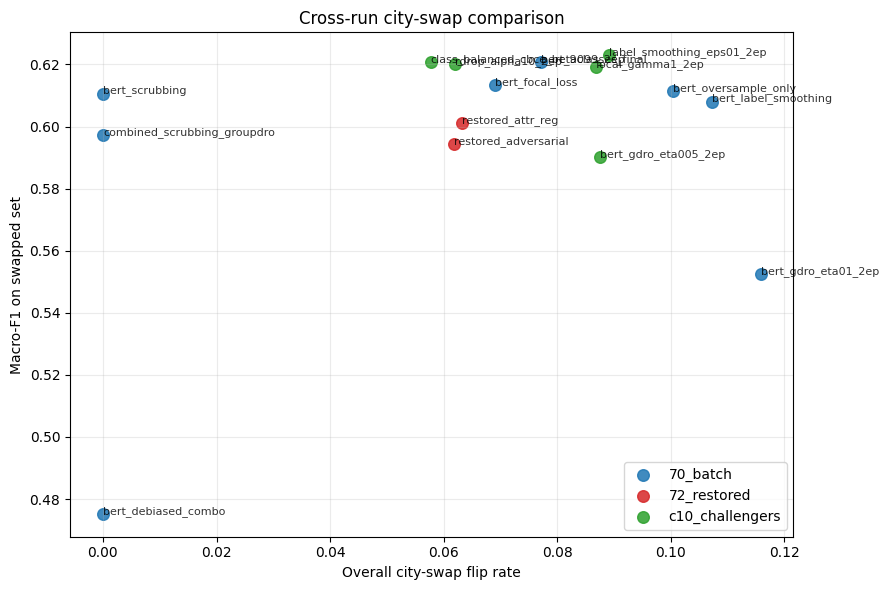

In [12]:
if HAS_MPL:
    plot_df = compare_df[compare_df["status"] == "ok"].copy()
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = {"70_batch": "#1f77b4", "c10_challengers": "#2ca02c", "72_restored": "#d62728"}
    for source_run, chunk in plot_df.groupby("source_run"):
        ax.scatter(
            chunk["overall_flip_rate"],
            chunk["swap_macro_f1"],
            s=70,
            label=source_run,
            color=colors.get(source_run, "#7f7f7f"),
            alpha=0.85,
        )
        for _, row in chunk.iterrows():
            ax.annotate(row["model_name"], (row["overall_flip_rate"], row["swap_macro_f1"]), fontsize=8, alpha=0.8)

    ax.set_xlabel("Overall city-swap flip rate")
    ax.set_ylabel("Macro-F1 on swapped set")
    ax.set_title("Cross-run city-swap comparison")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "73_cross_run_city_swap_scatter.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("matplotlib is not installed; skipping scatter plot.")
